### Import dependencies Section

In [2]:
from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import AIMessage,ToolMessage
from langchain_core.messages import convert_to_messages ,convert_to_openai_messages

from jinja2 import  Template
from typing import Literal,Dict,Any,Annotated,List
from IPython.display import Image,display
from operator import add
from openai import  OpenAI
import random
import ast
import inspect
import instructor
import json

import openai
from utils.utils import get_tool_descriptions,format_ai_message

In [3]:
from langchain_openai import ChatOpenAI
from jinja2 import Template


#### Single Node Graph

In [23]:
# class State(BaseModel):
#     messages:str
#     answer:str=""
#     vibe:str

In [4]:
def append_vibe_query(state:State)->dict:
    return {
        "answer":f"{state.messages} {state.vibe}"
    }

In [5]:
workflow=StateGraph(State)

workflow.add_node("append_vibe_query",append_vibe_query)

workflow.add_edge(START,"append_vibe_query")
workflow.add_edge("append_vibe_query",END)

graph=workflow.compile()

In [6]:
initial_state={
    "messages":"Give Me some Vibe",
    "vibe":"I am Felling like a badass today "
}

In [7]:
result=graph.invoke(initial_state)

In [8]:
result

{'messages': 'Give Me some Vibe',
 'answer': 'Give Me some Vibe I am Felling like a badass today ',
 'vibe': 'I am Felling like a badass today '}

#### Conditional Graph

In [4]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage


In [64]:
# class State(BaseModel):
#     message:str
#     answer:str=""

In [20]:
def append_vibe_to_query(state:State)->dict:
    return {
        "answer":"I have to add some vibe"
    }

In [19]:
def router(state:State)->Literal['append_vibe_1',"append_vibe_2","append_vibe_3"]:
    vibes=["append_vibe_1","append_vibe_2","append_vibe_3"]
    vibe_path=random.choice(vibes)
    return vibe_path


In [18]:
def append_vibe_1(state:State)->dict:
    vibe="I am feeling a badass today"
    return {
        "answer":f"{state.answer} {vibe}"
    }

def append_vibe_3(state:State)->dict:
    vibe="I am feeling a Boss today"
    return {
        "answer":f"{state.answer} {vibe}"
    }


def append_vibe_2(state:State)->dict:
    vibe="I am feeling like a Leagend today"
    return {
        "answer":f"{state.answer} {vibe}"
    }



In [32]:
workflow=StateGraph(State)


workflow.add_node("append_vibe_to_query",append_vibe_to_query)
workflow.add_node("append_vibe_1",append_vibe_1)
workflow.add_node("append_vibe_2",append_vibe_2)
workflow.add_node("append_vibe_3",append_vibe_3)

workflow.add_conditional_edges("append_vibe_to_query",
    router

)
workflow.add_edge(START,"append_vibe_to_query")
workflow.add_edge("append_vibe_1",END)
workflow.add_edge("append_vibe_2",END)
workflow.add_edge("append_vibe_3",END)

graph=workflow.compile()


In [31]:
initial_state={
    "message":"Give Me some Vibe",
}

In [40]:
graph.invoke(initial_state)

{'message': 'Give Me some Vibe',
 'answer': 'I have to add some vibe I am feeling like a Leagend today'}

#### Agent Graph That perform to Tool

In [11]:
def append_value(query:str,vibe:str)->str:
    """Takes in a query and a and return a string with the 
    query and vibe append
    
    Args:
      query:The query to append the vibe to.
      vibe:The vibe to append to the query.
    
    Return:
       A string with the query and the vibe append.
    """

    return f"{query} {vibe}"



In [67]:

def append_vibes(query: str, vibe: str) -> str:
    """
    Takes in a query and a vibe and returns a new query with the vibe appended
    Args:
        query: The query to append vibes to
        vibe: The vibe to append to the query
    Returns:
        A string of the query with the vibe appended
    """
    return f"{query} {vibe}"

In [66]:
get_tool_descriptions([append_vibes])

[{'name': 'append_vibes',
  'description': 'Takes in a query and a vibe and returns a new query with the vibe appended',
  'parameters': {'type': 'object',
   'properties': {'query': {'type': 'string',
     'description': 'The query to append vibes to'},
    'vibe': {'type': 'string',
     'description': 'The vibe to append to the query'}}},
  'required': ['query', 'vibe'],
  'returns': {'type': 'string',
   'description': 'A string of the query with the vibe appended'}}]

In [89]:
class ToolCall(BaseModel):
    name:str
    arguments:dict

class State(BaseModel):
    query: str
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    available_tools:List[Dict[str,Any]]=[]
    final_answer: bool = False
    tool_calls:List[ToolCall]=[]

In [90]:
class AgentResponse(BaseModel):
    answer:str
    tool_calls:List[ToolCall]=Field(default_factory=list)

In [6]:
def agent_node(state: State) -> dict:
    prompt_template = """
    You are a helpful assistant that is generating vibes for a user.

    ## Instructions
    - You need to use the tools to add vibes to the user's query
    - Add a random vibe to the user's query

    <Available_tool>
    {{available_tools | tojson}}
    </Available tools>

    when you need to use a tool, format your response as:

    <tool_call>
    {"name: "tool_name","argument": {....}}
    </tool_call>

    Instruction:
    -You need to use the tools to add vibes to the user's query,
    -Add a random vibe to the user's query
    """

    template = Template(prompt_template)

    prompt = template.render(
        available_tools=state.available_tools
    )

    client = instructor.from_openai(OpenAI())

    response, raw_response = client.chat.completions.create_with_completion(
        model='gpt-4.1-mini',
        response_model=AgentResponse,
        messages=[{"role": "system", "content": prompt}, {"role": "user", "content": state.query}],
        temperature=0.5
    )

    ai_message = format_ai_message(response=response)

    return {
        "messages": [ai_message],
        "tool_calls": response.tool_calls
    }


In [92]:
def tool_router(state: State) -> str:
    if len(state.tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [93]:
workflow = StateGraph(State)

tools = [append_vibes]
tool_node = ToolNode(tools)
tool_description=get_tool_descriptions(tools)

workflow.add_node("agent_node",agent_node)
workflow.add_node("tool_node", tool_node)
workflow.add_edge(START, "agent_node")
workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)
workflow.add_edge("tool_node", END)

graph = workflow.compile()

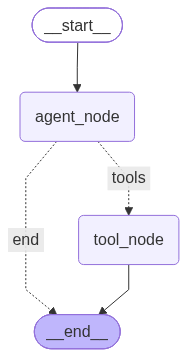

In [94]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [95]:
initial_state = {
    "query": "Give me some vibes!",
    "available_tools":tool_description
}

In [96]:
result = graph.invoke(initial_state)

In [97]:
result

{'query': 'Give me some vibes!',
 'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'chill and relaxed'}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='Give me some vibes! chill and relaxed', name='append_vibes', tool_call_id='call_0')],
 'available_tools': [{'name': 'append_vibes',
   'description': 'Takes in a query and a vibe and returns a new query with the vibe appended',
   'parameters': {'type': 'object',
    'properties': {'query': {'type': 'string',
      'description': 'The query to append vibes to'},
     'vibe': {'type': 'string',
      'description': 'The vibe to append to the query'}}},
   'required': ['query', 'vibe'],
   'returns': {'type': 'string',
    'description': 'A string of the query with the vibe appended'}}],
 'tool_calls': [ToolCall(name='append_vibes', arguments={'query': 'Give me some vibes!', 'vibe': 'ch

Agent Graph with Loopback from Tools(React agent)

In [18]:
def append_vibes(query:str,vibe:str)->str:
    """Takes in a query and a and return a string with the 
    query and vibe append
    
    Args:
      query:The query to append the vibe to.
      vibe:The vibe to append to the query.
    
    Return:
       A string with the query and the vibe append.
    """

    return f"{query} {vibe}"

In [24]:
class ToolCall(BaseModel):
    name:str
    arguments:dict

class State(BaseModel):
    query: str
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    available_tools:List[Dict[str,Any]]=[]
    final_answer: bool = False
    tool_calls:List[ToolCall]=[]
    iteration:int=0

class AgentResponse(BaseModel):
    answer:str
    tool_calls:List[ToolCall]=Field(default_factory=list)

In [26]:
def agent_node(state: State) -> dict:
    prompt_template = """
    You are a helpful assistant that is generating vibes for a user.

    ## Instructions
    - You need to use the tools to add vibes to the user's query
    - Add a random vibe to the user's query

    <Available_tool>
    {{available_tools | tojson}}
    </Available tools>

    when you need to use a tool, format your response as:

    <tool_call>
    {"name: "tool_name","argument": {....}}
    </tool_call>

    Instruction:
    -You need to use the tools to add vibes to the user's query,
    -Add a random vibe to the user's query
    """

    template = Template(prompt_template)

    prompt = template.render(
        available_tools=state.available_tools
    )

    client = instructor.from_openai(OpenAI())

    response, raw_response = client.chat.completions.create_with_completion(
        model='gpt-4.1-mini',
        response_model=AgentResponse,
        messages=[{"role": "system", "content": prompt}, {"role": "user", "content": state.query}],
        temperature=0.5
    )

    ai_message = format_ai_message(response=response)

    return {
        "messages": [ai_message],
        "tool_calls": [tc.model_dump() for tc in response.tool_calls],
        "iteration":state.iteration+1,
        "answer":response.answer
        
    }



In [11]:
def tool_router(state: State) -> str:
    """Decide wheather to continue or not"""
    if state.iteration>1:
        return "end"
    elif len(state.tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [28]:
workflow = StateGraph(State)

tools = [append_vibes]
tool_node = ToolNode(tools)
tool_description=get_tool_descriptions(tools)

workflow.add_node("agent_node",agent_node)
workflow.add_node("tool_node", tool_node)
workflow.add_edge(START, "agent_node")
workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)
workflow.add_edge("tool_node","agent_node")

graph = workflow.compile()

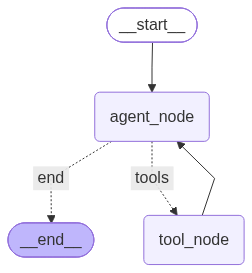

In [29]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
initial_state = {
    "query": "Give me some vibes!",
    "available_tools":tool_description
}

In [33]:
result=graph.invoke(initial_state)

In [34]:
result

{'query': 'Give me some vibes!',
 'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'chill and relaxing'}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='Give me some vibes! chill and relaxing', name='append_vibes', tool_call_id='call_0'),
  AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'chill and relaxed'}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[])],
 'iteration': 2,
 'answer': '',
 'available_tools': [{'name': 'append_vibes',
   'description': 'Takes in a query and a and return a string with the \nquery and vibe append',
   'parameters': {'type': 'object',
    'properties': {'query': {'type': 'string',
      'description': 'The query to append the vibe to.'},
     'vibe': {'type': 'string',
      'description